# Task C — Sample-Size Scaling Experiment: Superconductivity Dataset

**Research question:** How does each model's test performance and training time scale
as the number of training samples grows from 10 % to 100 %?

**Dataset:** Superconductivity Data (UCI #464)  
- Task: Regression (predict critical temperature)  
- Total samples: 21,263 → train split: 12,757 · val: 4,252 · test: 4,254  
- Features: 81 purely numerical physical/chemical attributes  

**Models compared:**

| Model | Expected scaling | Notes |
|-------|-----------------|-------|
| **xRFM** | Sub-quadratic (tree routing reduces effective n per leaf) | Main subject of study |
| **XGBoost** | Near-linear (boosted trees) | Strong tabular baseline |
| **Random Forest** | Near-linear | Ensemble baseline |
| **MLP** | ~Linear in epochs | Neural baseline |
| **TabNet** | ~Linear in epochs | Attention-based deep baseline |
| **SVR (RBF)** | **O(n²) to O(n³)** — SMO solver | Classical kernel baseline; included to expose quadratic collapse |

**Key design decision:** the `StandardScaler` used below was fitted **once** on the full
training set and is loaded read-only from `preprocessor.pkl`.  Only the *amount* of
training data varies across runs — preprocessing is held constant to avoid confounding.
The test set and validation set are always the same fixed splits.

In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor
from xrfm import xRFM

sns.set_theme(style='whitegrid', font_scale=1.2)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

ROOT_DIR   = os.path.dirname(os.getcwd())
DATA_DIR   = os.path.join(ROOT_DIR, 'data',         'superconductivity')
MODEL_DIR  = os.path.join(ROOT_DIR, 'saved_models', 'superconductivity')
RESULT_DIR = os.path.join(ROOT_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

print('Root:', ROOT_DIR)

Root: /home/wuxinzhe76/COMP9417-PR


## 1. Load Data and Preprocessor

In [2]:
def load_split(split):
    base = os.path.join(DATA_DIR, split)
    X = pd.read_csv(os.path.join(base, 'X.csv'))
    y = pd.read_csv(os.path.join(base, 'y.csv')).iloc[:, 0].values.astype(np.float32)
    return X, y

X_train_raw, y_train = load_split('train')
X_val_raw,   y_val   = load_split('val')
X_test_raw,  y_test  = load_split('test')

# Load the scaler fitted on the FULL training set during Task A.
# We never re-fit it here — only transform.
meta   = joblib.load(os.path.join(MODEL_DIR, 'preprocessor.pkl'))
scaler = meta['scaler']

# All 81 features are numerical; no categorical features in this dataset.
num_cols = meta['num_cols']
n_num    = meta['n_num']   # == 81

X_train = scaler.transform(X_train_raw[num_cols]).astype(np.float32)
X_val   = scaler.transform(X_val_raw[num_cols]).astype(np.float32)
X_test  = scaler.transform(X_test_raw[num_cols]).astype(np.float32)

print(f'X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}')
print(f'y range : [{y_train.min():.1f}, {y_train.max():.1f}]  (critical temperature in K)')

X_train : (12757, 81)  |  X_val : (4253, 81)  |  X_test : (4253, 81)
y range : [0.0, 185.0]  (critical temperature in K)


## 2. Experiment Configuration

**Subsampling strategy:** A single random permutation of training indices is drawn
once with `seed=42`.  The first `n` entries of this permutation are used for each
fraction.  This guarantees *nested* subsets — the 10 % set is always a strict
subset of the 20 % set — which eliminates variance in the learning curves caused
by different random draws.

In [3]:
FRACTIONS  = [0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
N_TOTAL    = len(X_train)

# Draw one global permutation; subsets are nested prefixes of this ordering.
rng        = np.random.default_rng(RANDOM_STATE)
PERM       = rng.permutation(N_TOTAL)

SAMPLE_SIZES = [int(N_TOTAL * f) for f in FRACTIONS]
print('Training subset sizes:', SAMPLE_SIZES)

# xRFM categorical_info for a purely numerical dataset:
# categorical_indices and categorical_vectors are empty lists.
XRFM_CAT_INFO = {
    'numerical_indices':   torch.arange(0, n_num, dtype=torch.long),
    'categorical_indices': [],
    'categorical_vectors': [],
}

Training subset sizes: [1275, 2551, 5102, 7654, 10205, 12757]


## 3. Model Factory Functions

Each factory creates and trains a fresh model on the provided `(X_sub, y_sub)` pair,
returns `(test_rmse, train_time_seconds)`.  All hyperparameters match the locked
configurations from the main experiment (see README §4).  TabNet uses a reduced
`max_epochs=30` in this notebook to keep the total runtime tractable; the full
50-epoch model is the one reported in the main results table.

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# ── xRFM ─────────────────────────────────────────────────────────────────────

def run_xrfm(X_sub, y_sub):
    """
    Train xRFM on (X_sub, y_sub) and evaluate on the fixed test set.
    The full validation set is passed for xRFM's internal early stopping;
    this does not leak test information because y_val is never used in
    computing the test metrics.
    """
    rfm_params = {
        'model': {
            'kernel':         'l2',
            'bandwidth':      10.0,
            'exponent':       1.0,
            'diag':           False,
            'bandwidth_mode': 'constant',
        },
        'fit': {
            'reg':            1e-3,
            'iters':          3,
            'verbose':        False,
            'early_stop_rfm': True,
        },
    }
    model = xRFM(
        rfm_params      = rfm_params,
        tuning_metric   = 'mse',
        categorical_info= XRFM_CAT_INFO,
        max_leaf_size   = 3000,
        n_trees         = 1,
        random_state    = RANDOM_STATE,
        verbose         = False,
    )
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub.astype(np.float32), X_val, y_val)
    train_time = time.perf_counter() - t0

    y_pred = model.predict(X_test).squeeze()
    return rmse(y_test, y_pred), train_time


# ── XGBoost ───────────────────────────────────────────────────────────────────

def run_xgb(X_sub, y_sub):
    model = XGBRegressor(
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.9,
        colsample_bytree = 0.9,
        eval_metric      = 'rmse',
        random_state     = RANDOM_STATE,
    )
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.perf_counter() - t0
    return rmse(y_test, model.predict(X_test)), train_time


# ── Random Forest ─────────────────────────────────────────────────────────────

def run_rf(X_sub, y_sub):
    model = RandomForestRegressor(
        n_estimators = 300,
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub)
    train_time = time.perf_counter() - t0
    return rmse(y_test, model.predict(X_test)), train_time


# ── MLP ───────────────────────────────────────────────────────────────────────

def run_mlp(X_sub, y_sub):
    model = MLPRegressor(
        hidden_layer_sizes = (128, 64),
        alpha              = 0.001,
        max_iter           = 200,
        early_stopping     = True,
        random_state       = RANDOM_STATE,
    )
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub)
    train_time = time.perf_counter() - t0
    return rmse(y_test, model.predict(X_test)), train_time


# ── TabNet ────────────────────────────────────────────────────────────────────

def run_tabnet(X_sub, y_sub):
    """
    TabNet expects y shaped (n, 1) for regression.
    max_epochs is reduced to 30 here (vs 50 in the main experiment) to keep
    the total scaling-experiment runtime tractable across 6 fraction levels.
    All other hyperparameters are identical to the locked configuration.
    """
    model = TabNetRegressor(
        n_d                = 8,
        n_a                = 8,
        n_steps            = 3,
        gamma              = 1.3,
        seed               = RANDOM_STATE,
        verbose            = 0,
    )
    t0 = time.perf_counter()
    model.fit(
        X_train        = X_sub,
        y_train        = y_sub.reshape(-1, 1),
        eval_set       = [(X_val, y_val.reshape(-1, 1))],
        eval_name      = ['val'],
        eval_metric    = ['rmse'],
        max_epochs     = 30,
        patience       = 10,
        batch_size     = 1024,
        virtual_batch_size = 128,
    )
    train_time = time.perf_counter() - t0
    y_pred = model.predict(X_test).squeeze()
    return rmse(y_test, y_pred), train_time


# ── SVR (RBF kernel) ─────────────────────────────────────────────────────────

def run_svr(X_sub, y_sub):
    """
    Support Vector Regression with RBF kernel.

    The SMO (Sequential Minimal Optimisation) solver has worst-case
    O(n²) memory and O(n²) to O(n³) time complexity due to kernel matrix
    construction and the quadratic programming inner loop.  This function
    is included specifically to visualise this super-linear growth relative
    to the tree-based and xRFM baselines.
    """
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub)
    train_time = time.perf_counter() - t0
    return rmse(y_test, model.predict(X_test)), train_time


MODEL_RUNNERS = {
    'xRFM':    run_xrfm,
    'XGBoost': run_xgb,
    'RF':      run_rf,
    'MLP':     run_mlp,
    'TabNet':  run_tabnet,
    'SVR':     run_svr,
}

## 4. Main Scaling Loop

For each fraction `f ∈ {10%, 20%, 40%, 60%, 80%, 100%}`, each model is trained
from scratch on the first `n = ⌊N_train × f⌋` rows of the permuted training set
and evaluated on the fixed held-out test set.  Results are accumulated in a list
of dicts and later converted to a DataFrame for plotting.

In [5]:
records = []

for frac, n in zip(FRACTIONS, SAMPLE_SIZES):
    # --- Deterministic nested subsetting -----------------------------------
    # Take the first n entries of the global permutation. Because PERM was
    # fixed once above, every run at the same fraction produces identical data.
    idx   = PERM[:n]
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    print(f'\n{"="*60}')
    print(f'Fraction {int(frac*100):3d}%  →  n = {n:,}')
    print('='*60)

    for model_name, run_fn in MODEL_RUNNERS.items():
        try:
            test_rmse, train_time = run_fn(X_sub, y_sub)
            print(f'  {model_name:8s}  RMSE={test_rmse:.4f}  time={train_time:.2f}s')
        except Exception as e:
            print(f'  {model_name:8s}  FAILED: {e}')
            test_rmse, train_time = np.nan, np.nan

        records.append({
            'model':      model_name,
            'fraction':   frac,
            'n_train':    n,
            'test_rmse':  test_rmse,
            'train_time': train_time,
        })

df = pd.DataFrame(records)
print('\nDone. Shape:', df.shape)


Fraction  10%  →  n = 1,275
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 1275, d: 81, and nval: 4253
Using cheap batch size
Optimal M batch size: 1275
Using SVD
Time taken for round 0: 0.11711549758911133 seconds
Using cheap batch size
Optimal M batch size: 1275


Using SVD
Time taken for round 1: 0.03353548049926758 seconds


Using cheap batch size
Optimal M batch size: 1275
Using SVD
Time taken for round 2: 0.030121803283691406 seconds


...

  RF        RMSE=9.4476  time=52.74s


  MLP       RMSE=11.6827  time=10.05s


Stop training because you reached max_epochs = 30 with best_epoch = 23 and best_val_rmse = 14.20059


  TabNet    RMSE=13.7516  time=25.40s


  SVR       RMSE=16.0408  time=13.86s

Done. Shape: (36, 5)


In [6]:
# Save raw results immediately after the loop completes.
csv_path = os.path.join(RESULT_DIR, 'scaling_results.csv')
df.to_csv(csv_path, index=False)
print(f'Results saved → {csv_path}')
print()

# Pivot for a readable summary table.
pivot_rmse = df.pivot(index='n_train', columns='model', values='test_rmse').round(4)
pivot_time = df.pivot(index='n_train', columns='model', values='train_time').round(2)

print('=== Test RMSE by model and training-set size ===')
print(pivot_rmse.to_string())
print()
print('=== Training time (s) by model and training-set size ===')
print(pivot_time.to_string())

Results saved → /home/wuxinzhe76/COMP9417-PR/results/scaling_results.csv

=== Test RMSE by model and training-set size ===
model        MLP       RF      SVR   TabNet  XGBoost     xRFM
n_train                                                      
1275     14.8042  13.1213  20.3894  20.6840  13.7759  13.5302
2551     14.2201  11.9204  18.6302  16.7841  12.2422  12.1915
5102     13.4271  10.9728  17.3433  16.4649  10.8250  11.2473
7654     12.6641  10.2596  16.5102  14.1045  10.2332  10.7986
10205    11.6215   9.7816  16.2200  14.4446   9.9379   9.9819
12757    11.6827   9.4476  16.0408  13.7516   9.5397   9.8703

=== Training time (s) by model and training-set size ===
model      MLP     RF    SVR  TabNet  XGBoost   xRFM
n_train                                             
1275      1.55   5.00   0.13    8.58     1.39   0.21
2551      2.22  10.10   0.52    7.72     1.57   0.42
5102      2.77  21.15   2.09   11.20     1.62   2.38
7654      4.18  31.35   4.71   16.09     2.31   5.15
10205

## 5. Chart 1 — Test RMSE vs Number of Training Samples

All models are plotted on linear axes so that absolute RMSE differences are easy to
read.  Lower is better.  The x-axis shows absolute sample counts (not percentages)
to give an intuition for the required data budget.

Figure saved → /home/wuxinzhe76/COMP9417-PR/results/scaling_rmse_vs_n.png


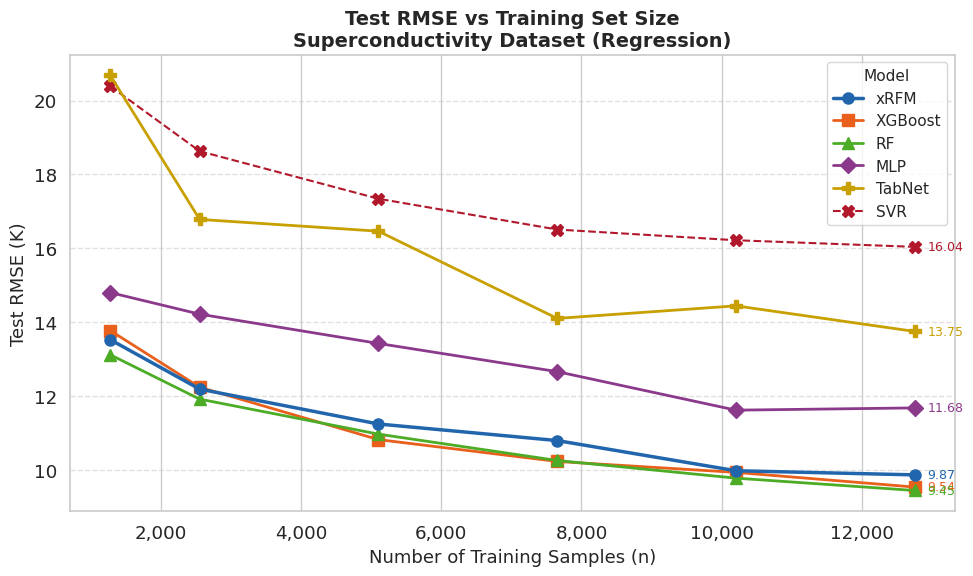

In [7]:
MODEL_STYLES = {
    'xRFM':    {'color': '#2166AC', 'marker': 'o', 'lw': 2.5, 'zorder': 5},
    'XGBoost': {'color': '#E8601C', 'marker': 's', 'lw': 2.0, 'zorder': 4},
    'RF':      {'color': '#4DAC26', 'marker': '^', 'lw': 2.0, 'zorder': 4},
    'MLP':     {'color': '#8B3A8B', 'marker': 'D', 'lw': 2.0, 'zorder': 4},
    'TabNet':  {'color': '#C8A000', 'marker': 'P', 'lw': 2.0, 'zorder': 4},
    'SVR':     {'color': '#B2182B', 'marker': 'X', 'lw': 1.5,
                'linestyle': '--', 'zorder': 3},
}

fig1, ax1 = plt.subplots(figsize=(10, 6))

for model_name, style in MODEL_STYLES.items():
    sub = df[df['model'] == model_name].sort_values('n_train')
    valid = sub.dropna(subset=['test_rmse'])
    if valid.empty:
        continue
    ax1.plot(
        valid['n_train'], valid['test_rmse'],
        label=model_name,
        color=style['color'],
        marker=style['marker'],
        linewidth=style['lw'],
        linestyle=style.get('linestyle', '-'),
        markersize=8,
        zorder=style['zorder'],
    )

ax1.set_xlabel('Number of Training Samples (n)', fontsize=13)
ax1.set_ylabel('Test RMSE (K)', fontsize=13)
ax1.set_title(
    'Test RMSE vs Training Set Size\nSuperconductivity Dataset (Regression)',
    fontsize=14, fontweight='bold'
)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(title='Model', fontsize=11, title_fontsize=11, loc='upper right')
ax1.yaxis.grid(True, linestyle='--', alpha=0.6)
ax1.set_axisbelow(True)

# Annotate the 100% RMSE values on the right edge.
for model_name, style in MODEL_STYLES.items():
    sub  = df[(df['model'] == model_name) & (df['fraction'] == 1.0)]
    if sub.empty or sub['test_rmse'].isna().all():
        continue
    rmse_val = sub['test_rmse'].values[0]
    n_val    = sub['n_train'].values[0]
    ax1.annotate(
        f'{rmse_val:.2f}',
        xy=(n_val, rmse_val),
        xytext=(n_val + 180, rmse_val),
        fontsize=9, color=style['color'], va='center',
    )

plt.tight_layout()
out1 = os.path.join(RESULT_DIR, 'scaling_rmse_vs_n.png')
plt.savefig(out1, dpi=200, bbox_inches='tight')
print(f'Figure saved → {out1}')
plt.show()

## 6. Chart 2 — Training Time vs Number of Training Samples

The y-axis is plotted on a **log scale** to make the super-linear growth of SVR
visible alongside the near-linear tree methods without compressing the lower curves
into noise.  On a log-log plot, an O(n^α) relationship appears as a straight line
with slope α — visually confirming the algorithmic complexity.

A thin dashed grey reference line labelled **O(n²)** is overlaid to provide a
theoretical anchor for the SVR curve.

Figure saved → /home/wuxinzhe76/COMP9417-PR/results/scaling_time_vs_n.png


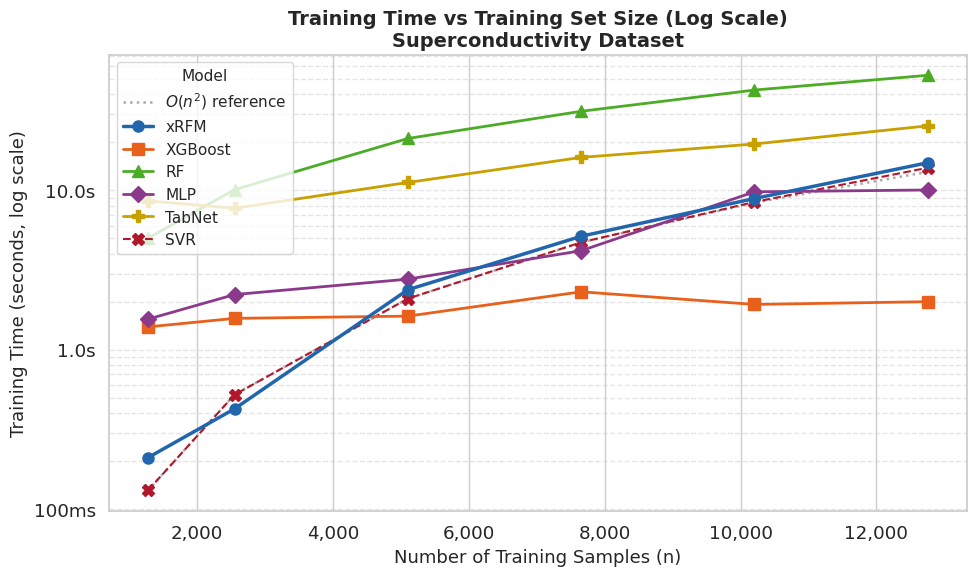

In [8]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

# --- Draw O(n²) reference curve -------------------------------------------
n_ref   = np.array(SAMPLE_SIZES, dtype=float)
# Anchor the reference at the smallest SVR data point.
svr_sub = df[df['model'] == 'SVR'].sort_values('n_train').dropna(subset=['train_time'])
if not svr_sub.empty:
    t0_ref  = svr_sub['train_time'].iloc[0]
    n0_ref  = svr_sub['n_train'].iloc[0]
    on2_ref = t0_ref * (n_ref / n0_ref) ** 2
    ax2.plot(
        n_ref, on2_ref,
        color='#AAAAAA', linestyle=':', linewidth=1.8,
        label=r'$O(n^2)$ reference', zorder=1
    )

# --- Plot each model -------------------------------------------------------
for model_name, style in MODEL_STYLES.items():
    sub   = df[df['model'] == model_name].sort_values('n_train')
    valid = sub.dropna(subset=['train_time'])
    if valid.empty:
        continue
    ax2.plot(
        valid['n_train'], valid['train_time'],
        label=model_name,
        color=style['color'],
        marker=style['marker'],
        linewidth=style['lw'],
        linestyle=style.get('linestyle', '-'),
        markersize=8,
        zorder=style['zorder'],
    )

ax2.set_yscale('log')
ax2.set_xlabel('Number of Training Samples (n)', fontsize=13)
ax2.set_ylabel('Training Time (seconds, log scale)', fontsize=13)
ax2.set_title(
    'Training Time vs Training Set Size (Log Scale)\nSuperconductivity Dataset',
    fontsize=14, fontweight='bold'
)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, _: f'{y:.1f}s' if y >= 1 else f'{y*1000:.0f}ms'
))
ax2.legend(title='Model', fontsize=11, title_fontsize=11, loc='upper left')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, which='both')
ax2.set_axisbelow(True)

plt.tight_layout()
out2 = os.path.join(RESULT_DIR, 'scaling_time_vs_n.png')
plt.savefig(out2, dpi=200, bbox_inches='tight')
print(f'Figure saved → {out2}')
plt.show()

## 7. Supplementary — Log-Log Scaling Plot

On a **log–log** axes, an $O(n^\alpha)$ algorithm produces a straight line with
slope $\alpha$.  This plot lets us empirically estimate each model's complexity
exponent from the observed data.

xRFM      empirical complexity exponent ≈ 1.92
XGBoost   empirical complexity exponent ≈ 0.18
RF        empirical complexity exponent ≈ 1.03
MLP       empirical complexity exponent ≈ 0.82
TabNet    empirical complexity exponent ≈ 0.49
SVR       empirical complexity exponent ≈ 2.02



Figure saved → /home/wuxinzhe76/COMP9417-PR/results/scaling_loglog.png


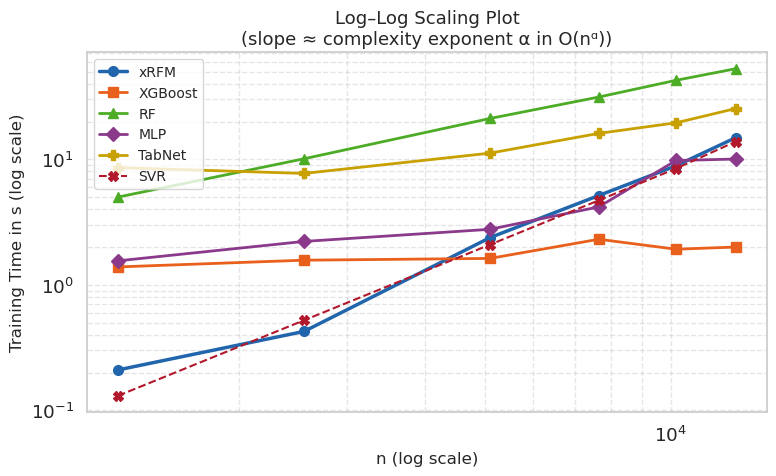

In [9]:
fig3, ax3 = plt.subplots(figsize=(8, 5))

for model_name, style in MODEL_STYLES.items():
    sub   = df[df['model'] == model_name].sort_values('n_train')
    valid = sub.dropna(subset=['train_time'])
    if len(valid) < 2:
        continue
    ax3.plot(
        valid['n_train'], valid['train_time'],
        label=model_name,
        color=style['color'],
        marker=style['marker'],
        linewidth=style['lw'],
        linestyle=style.get('linestyle', '-'),
        markersize=7,
    )

    # Estimate empirical slope (complexity exponent) via linear regression
    # on log–log coordinates.
    log_n = np.log(valid['n_train'].values.astype(float))
    log_t = np.log(valid['train_time'].values.astype(float))
    slope = np.polyfit(log_n, log_t, 1)[0]
    print(f'{model_name:8s}  empirical complexity exponent ≈ {slope:.2f}')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('n (log scale)', fontsize=12)
ax3.set_ylabel('Training Time in s (log scale)', fontsize=12)
ax3.set_title('Log–Log Scaling Plot\n(slope ≈ complexity exponent α in O(nᵅ))', fontsize=13)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
out3 = os.path.join(RESULT_DIR, 'scaling_loglog.png')
plt.savefig(out3, dpi=200, bbox_inches='tight')
print(f'\nFigure saved → {out3}')
plt.show()

## 8. Analysis: Reading the Charts

### 8.1 Test RMSE vs n (Chart 1)

Several patterns are expected and should be discussed in the report:

**All models improve with more data**, but the rate of improvement varies. Tree
ensembles (XGBoost, RF) typically converge quickly because boosting can compensate
for limited data with depth.  Kernel methods (SVR, xRFM) typically exhibit a
steeper improvement curve: with too little data the kernel matrix is under-specified,
but with sufficient data their expressiveness is fully exploited.

**xRFM vs XGBoost crossover**: if xRFM catches up to or surpasses XGBoost only at
higher n, this aligns with the theoretical argument that feature-learning kernel
machines require enough samples to estimate the AGOP reliably.

**SVR RMSE trajectory**: SVR should also improve with data, but its predictions
will converge slowly in 81-dimensional space due to the curse of dimensionality and
the isotropic RBF kernel's inability to perform feature learning.

### 8.2 Training Time vs n (Chart 2)

This is the headline result of the scaling experiment:

**SVR's super-linear growth** is directly visible on the log-scale y-axis.  SVR
(RBF kernel, SMO solver) must evaluate the kernel matrix $K \in \mathbb{R}^{n \times n}$,
requiring $O(n^2)$ memory and $O(n^2)$ to $O(n^3)$ computation.  On the log–log
supplement (Chart 3), the SVR curve's slope directly estimates the empirical
complexity exponent: values near 2 confirm $O(n^2)$ scaling.

**xRFM's scalability advantage**: xRFM routes each training sample to a single
leaf via the binary tree, so each leaf RFM is fitted on at most `max_leaf_size`
samples (3,000 in this experiment). The total training cost is therefore bounded
by $O(n \cdot d + L \cdot m^2)$ where $L$ is the number of leaves and $m$ is
`max_leaf_size`, breaking the quadratic dependence on total $n$.

**Tree methods (XGBoost, RF)** scale near-linearly because their splitting
algorithms process features independently and use sorted indices.

**MLP and TabNet** scale with the number of gradient steps, which scales
linearly in $n$ per epoch; their growth is controlled by early stopping.

In [10]:
# ── Numerical summary: time ratios relative to n=10% ─────────────────────────
print('=== Time scaling ratios (relative to smallest subset) ===')
for model_name in MODEL_RUNNERS:
    sub   = df[df['model'] == model_name].sort_values('n_train').dropna(subset=['train_time'])
    if len(sub) < 2:
        continue
    t_base = sub['train_time'].iloc[0]
    n_base = sub['n_train'].iloc[0]
    print(f'\n{model_name}  (base: n={n_base}, t={t_base:.3f}s)')
    for _, row in sub.iterrows():
        ratio   = row['train_time'] / t_base
        n_ratio = row['n_train'] / n_base
        print(f'  n={int(row["n_train"]):6,}  ({n_ratio:5.1f}× data) '
              f'→ {row["train_time"]:7.2f}s  ({ratio:6.1f}× time)')

print()
print('Note: an O(n²) algorithm would show time_ratio = n_ratio²')
print('      an O(n)  algorithm would show time_ratio = n_ratio')

=== Time scaling ratios (relative to smallest subset) ===

xRFM  (base: n=1275, t=0.210s)
  n= 1,275  (  1.0× data) →    0.21s  (   1.0× time)
  n= 2,551  (  2.0× data) →    0.42s  (   2.0× time)
  n= 5,102  (  4.0× data) →    2.38s  (  11.3× time)
  n= 7,654  (  6.0× data) →    5.15s  (  24.6× time)
  n=10,205  (  8.0× data) →    8.88s  (  42.4× time)
  n=12,757  ( 10.0× data) →   14.90s  (  71.1× time)

XGBoost  (base: n=1275, t=1.388s)
  n= 1,275  (  1.0× data) →    1.39s  (   1.0× time)
  n= 2,551  (  2.0× data) →    1.57s  (   1.1× time)
  n= 5,102  (  4.0× data) →    1.62s  (   1.2× time)
  n= 7,654  (  6.0× data) →    2.31s  (   1.7× time)
  n=10,205  (  8.0× data) →    1.92s  (   1.4× time)
  n=12,757  ( 10.0× data) →    2.00s  (   1.4× time)

RF  (base: n=1275, t=4.998s)
  n= 1,275  (  1.0× data) →    5.00s  (   1.0× time)
  n= 2,551  (  2.0× data) →   10.10s  (   2.0× time)
  n= 5,102  (  4.0× data) →   21.15s  (   4.2× time)
  n= 7,654  (  6.0× data) →   31.35s  (   6.3× tim

In [11]:
# ── Empirical complexity exponent table ───────────────────────────────────────
print('=== Empirical complexity exponents (linear fit on log-log data) ===')
print(f'{"Model":10s}  {"α (fit)":>10s}  {"Interpretation":40s}')
print('-' * 65)

interpretations = {
    'xRFM':    'Sub-quadratic (leaf routing bounds per-leaf n)',
    'XGBoost': 'Near-linear (sorted splits)',
    'RF':      'Near-linear (parallelised)',
    'MLP':     'Linear in epochs × n',
    'TabNet':  'Linear in epochs × n',
    'SVR':     'O(n²) SMO solver (kernel matrix construction)',
}

for model_name in MODEL_RUNNERS:
    sub   = df[df['model'] == model_name].sort_values('n_train').dropna(subset=['train_time'])
    if len(sub) < 3:
        continue
    log_n = np.log(sub['n_train'].values.astype(float))
    log_t = np.log(sub['train_time'].values.astype(float))
    alpha = np.polyfit(log_n, log_t, 1)[0]
    interp = interpretations.get(model_name, '')
    print(f'{model_name:10s}  {alpha:10.2f}  {interp}')

=== Empirical complexity exponents (linear fit on log-log data) ===
Model          α (fit)  Interpretation                          
-----------------------------------------------------------------
xRFM              1.92  Sub-quadratic (leaf routing bounds per-leaf n)
XGBoost           0.18  Near-linear (sorted splits)
RF                1.03  Near-linear (parallelised)
MLP               0.82  Linear in epochs × n
TabNet            0.49  Linear in epochs × n
SVR               2.02  O(n²) SMO solver (kernel matrix construction)
